<h1 style="text-align: center;">Life Satisfaction Prediction using GDP per Capita</h1>

**Assignment Note**

This assignment is not intended to be a full project. It serves as a follow up to reinforce the
concepts we have covered in lecture so far. More comprehensive analyses and detailed
projects will be introduced as we progress further into the course

## 🤔📚 Learning Objectives

- Load and visualize real-world data.
- Train and compare regression models using Scikit-Learn.
- Interpret model outputs and discuss generalization.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

# Part 1: Data Exploration and Visualization (20 marks)

**Q1 (5 marks)** Load the dataset lifesat.csv and display the first 5 rows.

In [3]:
df = pd.read_csv("datasets/lifesat.csv")
df.head()

,Country,GDP per capita (USD),Life satisfaction
0,Russia,26456.387938,5.8
1,Greece,27287.083401,5.4
2,Turkey,28384.987785,5.5
3,Latvia,29932.493910,5.9
4,Hungary,31007.768407,5.6


**Q2 (5 marks)** Print basic info and summary statistics 

In [4]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               27 non-null     object 
 1   GDP per capita (USD)  27 non-null     float64
 2   Life satisfaction     27 non-null     float64
dtypes: float64(2), object(1)
memory usage: 780.0+ bytes


,GDP per capita (USD),Life satisfaction
count,27.000000,27.000000
mean,41564.521771,6.566667
std,9631.452319,0.765607
min,26456.387938,5.400000
25%,33938.289305,5.900000
50%,41627.129269,6.800000
75%,49690.580269,7.300000
max,60235.728492,7.600000


**Q3 (10 marks)** Display a scatter plot for GDP per capita vs Life Satisfaction . Add labels, title, and discuss the observed relationship.

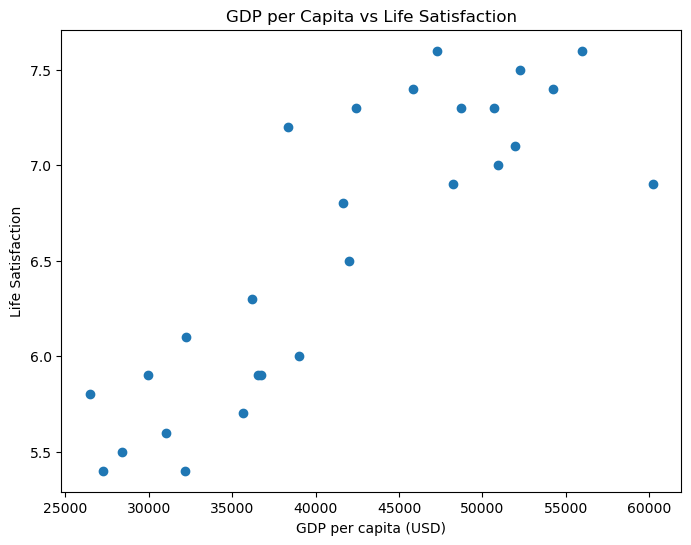

In [5]:
plt.figure(figsize=(8,6))
plt.scatter(df["GDP per capita (USD)"], df["Life satisfaction"])
plt.xlabel("GDP per capita (USD)")
plt.ylabel("Life Satisfaction")
plt.title("GDP per Capita vs Life Satisfaction")
plt.show()

Discuss the observed relationship:

So as i can see from scatter plot as dpg of the country increases life satisfaction increases also. And there are only a few cases when countries with higher gpd have less life satisfaction.

# Part 2: Linear Regression Model (30 marks)

**Q4 (5 marks)** Extract input (X) and target (y). Print their shapes


In [6]:
X = df[["GDP per capita (USD)"]]
y = df["Life satisfaction"]

print(X.shape)
print(y.shape)

(27, 1)
(27,)


**Q5 (10 marks)** Train a Linear Regression model & Display coefficient and intercept.

In [7]:
model = LinearRegression()
model.fit(X, y)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 6.778899694341219e-05
Intercept: 3.74904942737691


Coefficient = how much life satisfaction increases per $1 GDP increase<br/>
Intercept = predicted value when GDP = 0

**Q6 (10 marks)** Plot the predicted regression line from the model along with a scatter plot of the data.


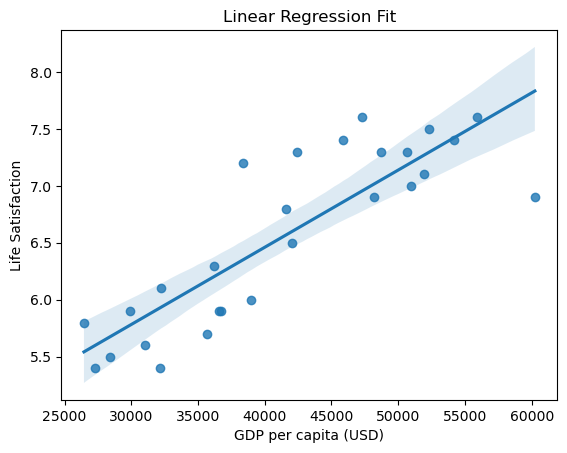

In [13]:
sns.regplot(x="GDP per capita (USD)", y="Life satisfaction", data=df)

plt.xlabel("GDP per capita (USD)")
plt.ylabel("Life Satisfaction")
plt.title("Linear Regression Fit")
plt.show()

**Q7 (5 marks)** Predict Life Satisfaction for GDP = 37,655.2 USD. Comment on result.

In [ ]:
gdp_value = pd.DataFrame([[37655.2]], columns=["GDP per capita (USD)"])
prediction = model.predict(gdp_value)

print(prediction[0])

# Part 3: K-Nearest Neighbors Regression (25 marks)

**Q8 (5 marks)** Train a KNeighborsRegressor (n_neighbors=3).

In [ ]:
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(X, y)

**Q9 (10 marks)** Predict Life Satisfaction for GDP = 37,655.2 USD and compare with Linear Regression.

In [ ]:
knn_prediction = knn.predict(gdp_value)

print("Linear Regression", prediction[0])
print("KNN (k=3):", knn_prediction[0])

Linear regression provides a global linear approximation, while KNN predicts based on nearby data points. KNN may better capture local patterns but can be less smooth in some cases.

**Q10 (10 marks)** Use n_neighbors 1, 3, 5, and 10 and print the predicted values of life satisfaction in Q10. Plot the results using a line plot.

In [ ]:
k_values = [1, 2, 5, 7, 10, 12, 25]
predictions = []

for k in k_values:
    knn_model = KNeighborsRegressor(n_neighbors=k)
    knn_model.fit(X, y)
    pred = knn_model.predict(gdp_value)[0]
    predictions.append(pred)
    print(f"k={k}, Prediction={pred}")

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(k_values, predictions)
plt.title("How prediction changes with the increasing number of neighbors in knn")
plt.show()


In [ ]:
plt.scatter(X, model.predict(X))
